<a href="https://colab.research.google.com/github/VitorBZS/am-t4-s1a2026/blob/main/MultiNeuralCredit0616.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline SVM | Digest [Fase 1 census Base]

## Importar dados do Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [3]:
!pip -q install plotly
!pip -q install yellowbrick

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
import pickle

In [27]:
from sklearn.preprocessing import LabelEncoder
import pickle

with open('/content/drive/MyDrive/amt4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

# Encode the target labels
label_encoder = LabelEncoder()
Y_census_treinamento = label_encoder.fit_transform(Y_census_treinamento)
Y_census_teste = label_encoder.transform(Y_census_teste)

In [8]:
from sklearn.svm import SVC

In [9]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_treinamento, Y_census_treinamento)

SVC(C=2.0, random_state=1)

In [10]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [11]:
svm_previsoes = svm_census.predict(X_census_teste)
svm_previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [12]:
accuracy_score(Y_census_teste, svm_census.predict(X_census_teste))

0.8485158648925282

In [13]:
confusion_matrix(Y_census_teste, svm_previsoes)

array([[3457,  236],
       [ 504,  688]])

In [14]:
from yellowbrick.classifier import ConfusionMatrix

0.8485158648925282

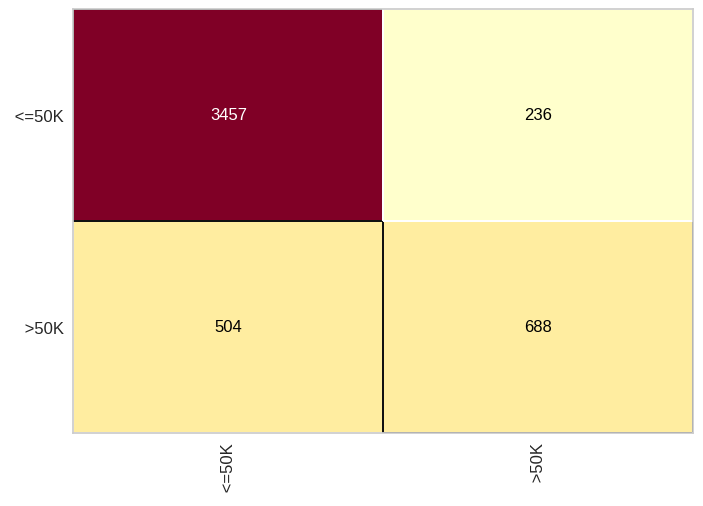

In [15]:
svm_cm = ConfusionMatrix(svm_census)
svm_cm.fit(X_census_treinamento, Y_census_treinamento)
svm_cm.score(X_census_teste, Y_census_teste)

In [16]:
print(classification_report(Y_census_teste, svm_previsoes))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.74      0.58      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline Redes Neurais | Digest [Fase 1 census Base]

In [17]:
from sklearn.neural_network import MLPClassifier

In [18]:
redeneural_census = MLPClassifier(verbose =True, max_iter=1000, tol=0.000010, solver='adam', hidden_layer_sizes=(100),
                                  activation='relu')
redeneural_census.fit(X_census_treinamento, Y_census_treinamento)

Iteration 1, loss = 0.38098967
Iteration 2, loss = 0.32521488
Iteration 3, loss = 0.31589505
Iteration 4, loss = 0.30817711
Iteration 5, loss = 0.30404562
Iteration 6, loss = 0.30081428
Iteration 7, loss = 0.29776348
Iteration 8, loss = 0.29492044
Iteration 9, loss = 0.29315237
Iteration 10, loss = 0.29102437
Iteration 11, loss = 0.28982095
Iteration 12, loss = 0.28743469
Iteration 13, loss = 0.28623563
Iteration 14, loss = 0.28511499
Iteration 15, loss = 0.28331242
Iteration 16, loss = 0.28211531
Iteration 17, loss = 0.28053045
Iteration 18, loss = 0.27938106
Iteration 19, loss = 0.27820534
Iteration 20, loss = 0.27700137
Iteration 21, loss = 0.27576683
Iteration 22, loss = 0.27508423
Iteration 23, loss = 0.27398669
Iteration 24, loss = 0.27255454
Iteration 25, loss = 0.27237897
Iteration 26, loss = 0.27079900
Iteration 27, loss = 0.26959714
Iteration 28, loss = 0.26856169
Iteration 29, loss = 0.26695724
Iteration 30, loss = 0.26736837
Iteration 31, loss = 0.26679777
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [19]:
redeneural_census.out_activation_

'logistic'

In [20]:
previsores_randeural = redeneural_census.predict(X_census_teste)
previsores_randeural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [21]:
accuracy_score(Y_census_teste, previsores_randeural)

0.8257932446264074

0.8257932446264074

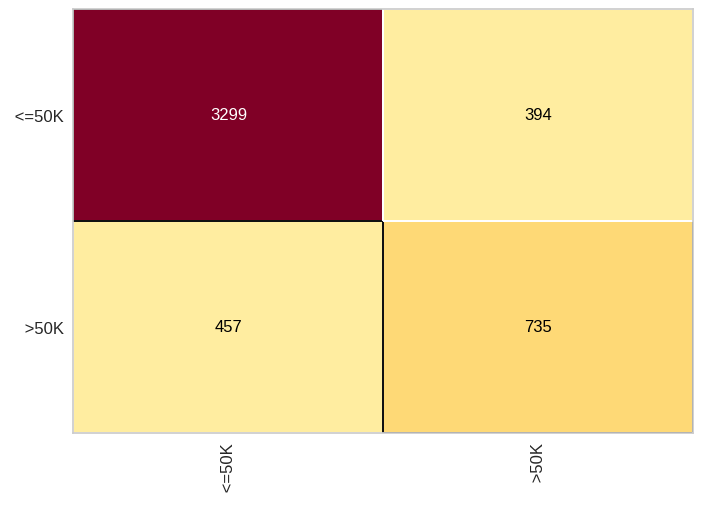

In [22]:
rn_cm = ConfusionMatrix(redeneural_census)
rn_cm.fit(X_census_treinamento, Y_census_treinamento)
rn_cm.score(X_census_teste, Y_census_teste)

In [23]:
print(classification_report(Y_census_teste, previsores_randeural))

              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.89      3693
        >50K       0.65      0.62      0.63      1192

    accuracy                           0.83      4885
   macro avg       0.76      0.75      0.76      4885
weighted avg       0.82      0.83      0.82      4885



# Pipeline de Preparação dos Dados | census_Base[Fase 1]

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [29]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1,2]}

In [30]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid = parametros)
grid_census.fit(X_census_treinamento, Y_census_treinamento)
melhor_parametro_census = grid_census.best_params_
melhor_resultado_census = grid_census.best_score_
print(melhor_parametro_census)
print(melhor_resultado_census)

{'n_neighbors': 20, 'p': 1}
0.8327430212885943
